In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [4]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

C:\Users\hercd\AppData\Local\Temp\ipykernel_13748\1967777196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['solarradiation'].fillna(mean_13_00, inplace=True)


In [5]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,Partially cloudy
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,"Rain, Partially cloudy"


In [6]:
kwh_data = pd.get_dummies(kwh_data, columns= ['conditions'])
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,"conditions_Rain, Overcast","conditions_Rain, Partially cloudy",conditions_Snow,"conditions_Snow, Overcast","conditions_Snow, Partially cloudy","conditions_Snow, Rain","conditions_Snow, Rain, Overcast","conditions_Snow, Rain, Partially cloudy"
datetime,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,True,False,False,False,False,False,False,False,False,False,False,False
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,True,False,False,False,False,False,False,False,False,False,False,False
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,False,False,True,False,False,False,False,False,False,False,False,False
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,False,False,True,False,False,False,False,False,False,False,False,False
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,False,False,False,False,False,True,False,False,False,False,False,False
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,False,False,False,False,False,True,False,False,False,False,False,False


In [7]:
kwh_data.iloc[:, 6:] = np.where(kwh_data.iloc[:, 6:] == False, 0, 1 )
kwh_data

C:\Users\hercd\AppData\Local\Temp\ipykernel_13748\3369268812.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  kwh_data.iloc[:, 6:] = np.where(kwh_data.iloc[:, 6:] == False, 0, 1 )
C:\Users\hercd\AppData\Local\Temp\ipykernel_13748\3369268812.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  kwh_data.iloc[:, 6:] = np.where(kwh_data.iloc[:, 6:] == False, 0, 1 )
C:\Users\hercd\AppData\Local\Temp\ipykernel_13748\3369268812.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 1 ... 0 1 1]' has dtype incompatible with bool, please explicitly cast to a compatible

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,"conditions_Rain, Overcast","conditions_Rain, Partially cloudy",conditions_Snow,"conditions_Snow, Overcast","conditions_Snow, Partially cloudy","conditions_Snow, Rain","conditions_Snow, Rain, Overcast","conditions_Snow, Rain, Partially cloudy"
datetime,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,0,0,1,0,0,0,0,0,0,0,0,0
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,0,0,1,0,0,0,0,0,0,0,0,0
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,0,0,0,0,0,1,0,0,0,0,0,0
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,0,0,0,0,0,1,0,0,0,0,0,0


In [8]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)

In [9]:
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,"conditions_Rain, Overcast","conditions_Rain, Partially cloudy",conditions_Snow,"conditions_Snow, Overcast","conditions_Snow, Partially cloudy","conditions_Snow, Rain","conditions_Snow, Rain, Overcast","conditions_Snow, Rain, Partially cloudy",Kwh
datetime,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,0,0,1,0,0,0,0,0,0,0,0,0,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,0,0,0,0,0,1,0,0,0,0,0,0,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,0,0,0,0,0,1,0,0,0,0,0,0,0.0000


In [10]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :18]]
        x.append(row)
        real_val = df_as_np[i + size][18]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [11]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :6])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657


In [13]:
df_scaled_kwh.index = data.index
df_scaled_kwh.columns = ['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation']
df_scaled_kwh

,temp,humidity,windgust,winddir,cloudcover,solarradiation
datetime,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640
...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603


In [14]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data.iloc[:, 6:]], axis= 1)
df_scaled_kwh

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_Clear,conditions_Overcast,conditions_Partially cloudy,conditions_Rain,"conditions_Rain, Overcast","conditions_Rain, Partially cloudy",conditions_Snow,"conditions_Snow, Overcast","conditions_Snow, Partially cloudy","conditions_Snow, Rain","conditions_Snow, Rain, Overcast","conditions_Snow, Rain, Partially cloudy",Kwh
datetime,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,1,0,0,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,1,0,0,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0,0,1,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0,0,1,0,0,0,0,0,0,0,0,0,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0,0,1,0,0,0,0,0,0,0,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0,0,1,0,0,0,0,0,0,0,0,0,0.0592
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,0,0,0,0,0,1,0,0,0,0,0,0,0.0085
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0,0,0,0,0,1,0,0,0,0,0,0,0.0000


In [15]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.9*len(x_kwh))], y_kwh[:int(0.9*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.9*len(x_kwh)):int(0.95*len(x_kwh))], y_kwh[int(0.9*len(y_kwh)):int(0.95*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.95*len(x_kwh)):], y_kwh[int(0.95*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((19763, 24, 18), (19763,), (1098, 24, 18), (1098,), (1098, 24, 18), (1098,))

In [16]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [24]:
input_shape = (24, 18)

inputs = Input(shape=input_shape)

cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

lstm_out = LSTM(128, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out
attention_out = Attention()([query, value])

dropout_out = Dropout(0.2)(attention_out)

dense_out = Dense(128, activation="relu")(dropout_out)

flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │      3,520 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 12, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 64)    │        256 │ max_pooling1d_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 6, 128)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ max_pooling1d_3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 6, 128)    │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 6, 128)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 128)    │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6, 128)    │     16,512 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 178,241 (696.25 KB)

 Trainable params: 177,345 (692.75 KB)

 Non-trainable params: 896 (3.50 KB)

In [25]:
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
616/618 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0782 - root_mean_squared_error: 0.2699
Epoch 1: val_loss did not improve from 0.00796
618/618 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0780 - root_mean_squared_error: 0.2696 - val_loss: 0.0304 - val_root_mean_squared_error: 0.1744 - learning_rate: 0.0010
Epoch 2/40
614/618 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0181 - root_mean_squared_error: 0.1345
Epoch 2: val_loss did not improve from 0.00796
618/618 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0181 - root_mean_squared_error: 0.1344 - val_loss: 0.0264 - val_root_mean_squared_error: 0.1626 - learning_rate: 0.0010
Epoch 3/40
617/618 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0112 - root_mean_squared_error: 0.1057
Epoch 3: val_loss did not improve from 0.00796
618/618 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0112 - root_mean_squared_error: 0.1057 - val_loss: 0.0152 - val_root_mean_squared_error: 0.1231 - learning_rate: 0.0010
Epoch 4/40
614/618 ━━━━━━━━━━━━━━━━━━━

In [26]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-1098:].index

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


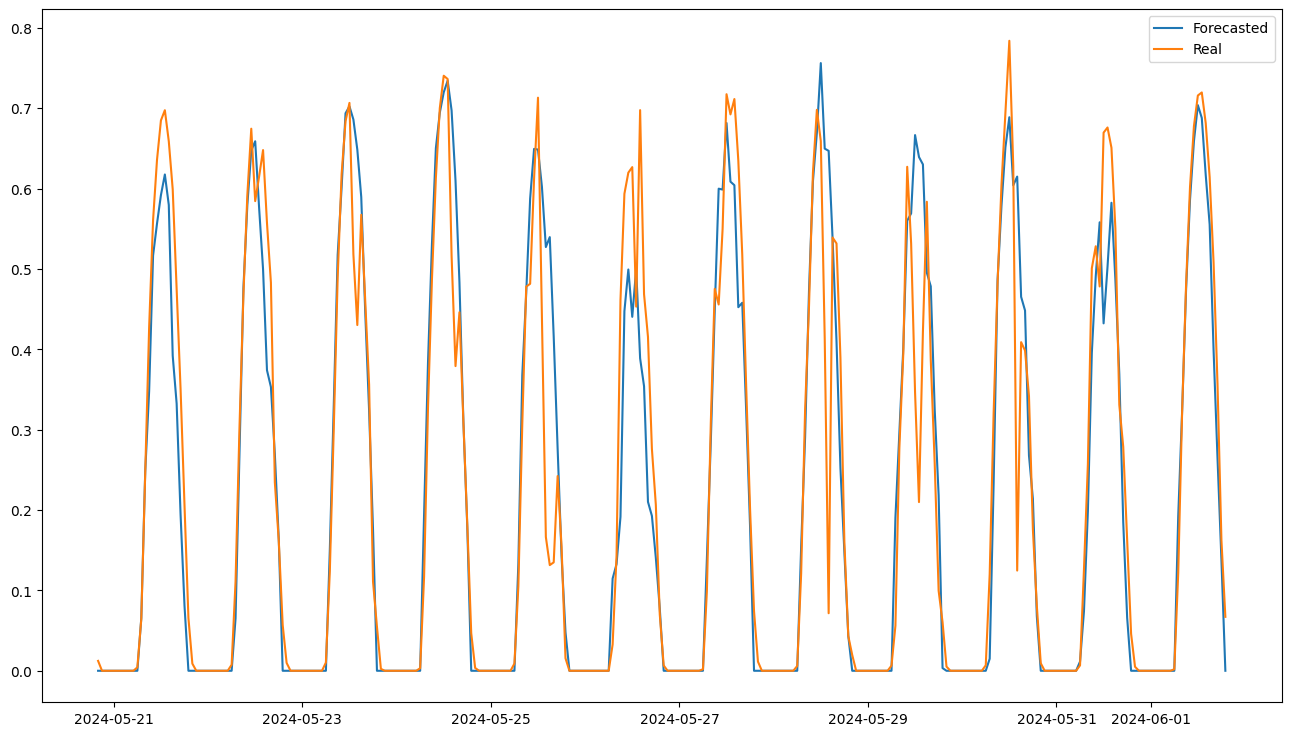

In [27]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][14:302], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][14:302], label="Real")
plt.legend()
plt.show()


In [23]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh    #0.92

Mean Squared Error = 0.00585 
Root Mean Squared Error = 0.07649


(0.9109646438929998, 0.00585109925146598)

# LabelEncoder

In [5]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,Partially cloudy
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,"Rain, Partially cloudy"


In [40]:
from sklearn.preprocessing import LabelEncoder

kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)

kwh_data

C:\Users\hercd\AppData\Local\Temp\ipykernel_2672\3357509997.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,2
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,2
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,2
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5


# Embedding Model

In [18]:
input_shape = (24, 18)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(16, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     21,248 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 16)    │      1,040 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 16)    │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,625 (88.38 KB)

 Trainable params: 22,465 (87.75 KB)

 Non-trainable params: 160 (640.00 B)

In [19]:
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
616/618 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0531 - root_mean_squared_error: 0.2246
Epoch 1: val_loss improved from inf to 0.01592, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0530 - root_mean_squared_error: 0.2244 - val_loss: 0.0159 - val_root_mean_squared_error: 0.1262 - learning_rate: 0.0010
Epoch 2/40
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0133 - root_mean_squared_error: 0.1154
Epoch 2: val_loss improved from 0.01592 to 0.01480, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0133 - root_mean_squared_error: 0.1154 - val_loss: 0.0148 - val_root_mean_squared_error: 0.1217 - learning_rate: 0.0010
Epoch 3/40
614/618 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0100 - root_mean_squared_error: 0.0999
Epoch 3: val_loss improved from 0.01480 to 0.01170, saving model to D:/Σπουδές/

In [20]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-1098:].index

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


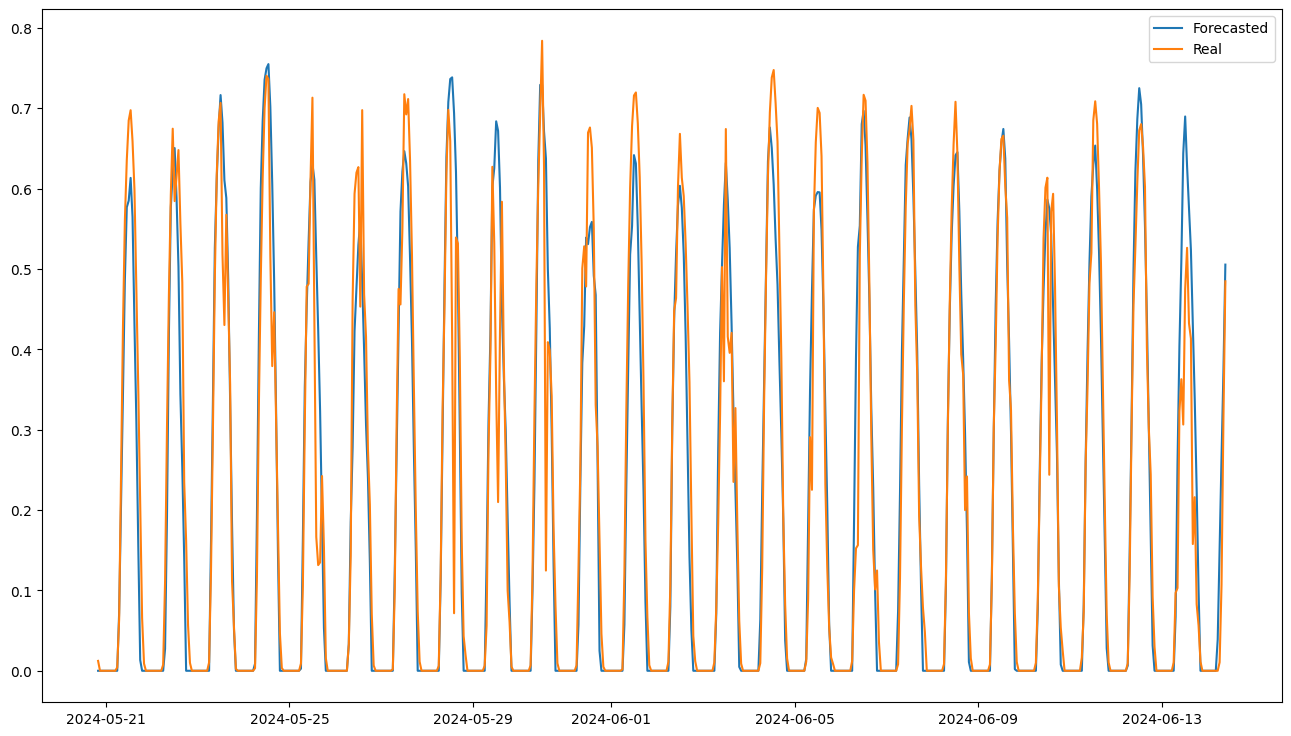

In [23]:
plt.figure(figsize=(16, 9))
plt.plot(test_results_kwh["Val Predictions"][14:604], label="Forecasted")
plt.plot(test_results_kwh["Real Data"][14:604], label="Real")
plt.legend()
plt.show()


In [22]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh    #0.92

Mean Squared Error = 0.00567 
Root Mean Squared Error = 0.07531


(0.9136891956890386, 0.005672051020836959)